## 0. Package Installation

In [1]:
# Install required libraries
!pip install kaggle
!pip install SimpleITK
!pip install --upgrade pip setuptools wheel
!pip install git+https://github.com/AIM-Harvard/pyradiomics.git

  Cloning https://github.com/AIM-Harvard/pyradiomics.git to /tmp/pip-req-build-dnfo7nan
  Running command git clone --filter=blob:none --quiet https://github.com/AIM-Harvard/pyradiomics.git /tmp/pip-req-build-dnfo7nan
  Resolved https://github.com/AIM-Harvard/pyradiomics.git to commit 8ed579383b44806651c463d5e691f3b2b57522ab
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyradiomics: filename=pyradiomics-3.1.1.dev111+g8ed579383-cp312-cp312-linux_x86_64.whl size=121732 sha256=fd408e882091e1e6d8c12bd95472c6d3f661a065fb7f1cdc3cba724d66c27a49
  Stored in directory: /tmp/pip-ephem-wheel-cache-s628j5b1/wheels/e2/99/a6/b2d774920a9e48d28ec790aa277aa8f49f531d2d6d63cd5c94
  Created wheel for docopt: filename=docopt

## 1. Dataset Preparation

In this section, we will download the **Chest CT-Scan Images** dataset from Kaggle using the Kaggle API. The dataset consists of chest CT-scan images categorized into four classes: three lung cancer types (adenocarcinoma, large cell carcinoma, squamous cell carcinoma) and one normal class. The dataset is already split into training, validation, and test folders.

**Data Source:**
*   **Title:** Chest CT-Scan Images
*   **Author:** Mohamed Hany
*   **URL:** https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
*   **License:** CC BY-NC-SA 4.0

In [26]:
# Import required libraries
import os

### Setting Up Kaggle API Key

To download data from Kaggle, you need an API key. This key is found in the `kaggle.json` file, which can be downloaded from your Kaggle account's 'My Account' section. To securely use this file in Colab:

1.  Download your `kaggle.json` file from your Kaggle profile and place it in the `/content/drive/MyDrive/pr_hw3_152120211071/` location in your Google Drive.
2.  Run the code block below to copy this file to the `.kaggle` directory and set the necessary permissions.

**Note:** Be careful not to leave your `kaggle.json` file in a public directory, as it contains sensitive credentials.

In [27]:
# Copy kaggle.json from Google Drive to .kaggle directory and set permissions.

# Create .kaggle directory
!mkdir -p ~/.kaggle

# Copy kaggle.json from the specified Google Drive path
!cp /content/drive/MyDrive/pr_hw3_152120211071/kaggle.json ~/.kaggle/

# Set file permissions
!chmod 600 ~/.kaggle/kaggle.json

### Downloading, Unzipping, and Moving the Dataset to Google Drive

Now, we will download the dataset using the Kaggle API, unzip the compressed file, and move it to your specified Google Drive folder.

In [38]:
# Download the dataset directly to Google Drive
zip_file_name = 'chest-ctscan-images.zip'
extracted_dir_name = 'chest_ctscan_images'
target_drive_path = '/content/drive/MyDrive/pr_hw3_152120211071'

# Create target Google Drive directory (does nothing if it exists)
!mkdir -p {target_drive_path}

# Download the dataset to the specified Google Drive path
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images -p {target_drive_path}

full_zip_path = os.path.join(target_drive_path, zip_file_name)
full_extracted_dir_path = os.path.join(target_drive_path, extracted_dir_name)

if os.path.exists(full_zip_path):
    # If a previously extracted directory exists, clean it up
    if os.path.exists(full_extracted_dir_path):
        print(f"Cleaning up existing '{extracted_dir_name}' directory...")
        !rm -r {full_extracted_dir_path}

    # Unzip the downloaded ZIP file directly to the Google Drive directory
    !unzip -q {full_zip_path} -d {target_drive_path}
    print(f"'{zip_file_name}' successfully unzipped to '{target_drive_path}'.")

    # Delete the downloaded ZIP file
    !rm {full_zip_path}
    print(f"'{zip_file_name}' cleaned up.")
else:
    print(f"Error: '{full_zip_path}' not found.")

Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
100% 119M/119M [00:01<00:00, 110MB/s]

'chest-ctscan-images.zip' successfully unzipped to '/content/drive/MyDrive/pr_hw3_152120211071'.
'chest-ctscan-images.zip' cleaned up.


In [39]:
import os

# Base path of the dataset
# According to user feedback, the 'Data' folder is directly under target_drive_path.
data_base_path = os.path.join(target_drive_path, 'Data')

print(f"\nDataset Class Analysis ({data_base_path}):\n")

# List classes in training, validation, and test sets
for sub_dir in ['train', 'valid', 'test']:
    path = os.path.join(data_base_path, sub_dir)
    if os.path.exists(path):
        classes = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
        print(f"{sub_dir.capitalize()} Set Classes: {classes}")
    else:
        print(f"Error: {sub_dir.capitalize()} set path not found: {path}")


Dataset Class Analysis (/content/drive/MyDrive/pr_hw3_152120211071/Data):

Train Set Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid Set Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test Set Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


In [40]:
from collections import Counter

print("\nClass-based Image Counts:")
for sub_dir in ['train', 'valid', 'test']:
    if y_raw[sub_dir]:
        class_counts = Counter(y_raw[sub_dir])
        print(f"\n{sub_dir.capitalize()} Set Class Distribution:")
        for class_name, count in class_counts.items():
            print(f"  {class_name}: {count} images")
    else:
        print(f"\n{sub_dir.capitalize()} Set: No labels found.")



Class-based Image Counts:

Train Set Class Distribution:
  adenocarcinoma: 195 images
  large.cell.carcinoma: 115 images
  normal: 148 images
  squamous.cell.carcinoma: 155 images

Valid Set Class Distribution:
  adenocarcinoma: 23 images
  large.cell.carcinoma: 21 images
  normal: 13 images
  squamous.cell.carcinoma: 15 images

Test Set Class Distribution:
  adenocarcinoma: 120 images
  large.cell.carcinoma: 51 images
  normal: 54 images
  squamous.cell.carcinoma: 90 images


## 2. Data Preprocessing

In this section, image data will be prepared for radiomic feature extraction. The steps include:

1.  **Loading and Preprocessing Images**: Load images from train, valid, and test sets, convert to grayscale, and resize to a fixed dimension (e.g., 224x224).
2.  **Creating Binary Masks**: Apply binary masks to each image using Otsu thresholding. These masks will ensure that radiomic features are extracted from the relevant region.
3.  **Encoding Labels**: Convert class labels to integer format and ensure consistent encoding across all sets (train, valid, test). Standardized labels will be used to resolve discrepancies in folder names.
4.  **Converting to SimpleITK Format**: Convert preprocessed images and masks to SimpleITK format before passing them to the feature extractor.

In [41]:
import cv2
import numpy as np
import SimpleITK as sitk
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os

# Fixed size for resizing images
IMG_SIZE = (224, 224)

# Function to standardize class names to handle discrepancies in folder names
def standardize_class_name(class_name):
    if 'adenocarcinoma' in class_name:
        return 'adenocarcinoma'
    elif 'large.cell.carcinoma' in class_name:
        return 'large.cell.carcinoma'
    elif 'squamous.cell.carcinoma' in class_name:
        return 'squamous.cell.carcinoma'
    elif 'normal' in class_name:
        return 'normal'
    else:
        # If an unexpected class name is encountered, return it as is (for error handling)
        return class_name

def preprocess_image(image_path):
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Warning: Could not load image: {image_path}")
        return None, None

    # Convert to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize to fixed size
    resized_img = cv2.resize(gray_img, IMG_SIZE)

    # Create binary mask with Otsu thresholding
    # Threshold value is determined automatically
    _, binary_mask = cv2.threshold(resized_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return resized_img, binary_mask

# Load, preprocess, and collect labels for datasets
X_raw = {'train': [], 'valid': [], 'test': []}
y_raw = {'train': [], 'valid': [], 'test': []}

# data_base_path variable was previously defined (e.g.: /content/drive/MyDrive/pr_hw3_152120211071/Data)

for sub_dir in ['train', 'valid', 'test']:
    current_set_path = os.path.join(data_base_path, sub_dir)
    if not os.path.exists(current_set_path):
        print(f"Error: {sub_dir.capitalize()} set path not found: {current_set_path}")
        continue

    print(f"\nProcessing images in {sub_dir.capitalize()} set...")
    for class_name_verbose in tqdm(os.listdir(current_set_path)):
        class_path = os.path.join(current_set_path, class_name_verbose)
        if os.path.isdir(class_path):
            # Get standardized class name
            standardized_label = standardize_class_name(class_name_verbose)

            for image_file in os.listdir(class_path):
                if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(class_path, image_file)
                    processed_image, binary_mask = preprocess_image(image_path)

                    if processed_image is not None and binary_mask is not None:
                        X_raw[sub_dir].append((processed_image, binary_mask))
                        y_raw[sub_dir].append(standardized_label)

print("\nPreprocessing complete.")

# Check data dimensions after preprocessing
for key in X_raw:
    print(f"{key.capitalize()} Set: {len(X_raw[key])} images, {len(y_raw[key])} labels")


Processing images in Train set...


100%|██████████| 4/4 [00:09<00:00,  2.28s/it]



Processing images in Valid set...


100%|██████████| 4/4 [00:01<00:00,  3.85it/s]



Processing images in Test set...


100%|██████████| 4/4 [00:04<00:00,  1.13s/it]


Preprocessing complete.
Train Set: 613 images, 613 labels
Valid Set: 72 images, 72 labels
Test Set: 315 images, 315 labels


In [42]:
# 3. Encode Labels to Integer Format

# Train LabelEncoder by combining all labels
all_labels = y_raw['train'] + y_raw['valid'] + y_raw['test']
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

# Encode labels for each dataset
y_train_encoded = label_encoder.transform(y_raw['train'])
y_valid_encoded = label_encoder.transform(y_raw['valid'])
y_test_encoded = label_encoder.transform(y_raw['test'])

print("\nLabel Encoding:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} = {i}")

print("\nEncoded Label Examples (Train):", y_train_encoded[:5])
print("Encoded Label Examples (Valid):", y_valid_encoded[:5])
print("Encoded Label Examples (Test):", y_test_encoded[:5])


Label Encoding:
adenocarcinoma = 0
large.cell.carcinoma = 1
normal = 2
squamous.cell.carcinoma = 3

Encoded Label Examples (Train): [0 0 0 0 0]
Encoded Label Examples (Valid): [0 0 0 0 0]
Encoded Label Examples (Test): [0 0 0 0 0]


In [43]:
# 4. Convert NumPy Arrays to SimpleITK Format

def convert_to_sitk(np_image, np_mask):
    # Create SimpleITK image object
    sitk_image = sitk.GetImageFromArray(np_image)
    # Create SimpleITK image object for mask
    sitk_mask = sitk.GetImageFromArray(np_mask)
    return sitk_image, sitk_mask

X_sitk = {'train': [], 'valid': [], 'test': []}

print("\nConverting to SimpleITK format...")
for sub_dir in X_raw:
    print(f"Converting data in {sub_dir.capitalize()} set...")
    for np_image, np_mask in tqdm(X_raw[sub_dir]):
        sitk_image, sitk_mask = convert_to_sitk(np_image, np_mask)
        X_sitk[sub_dir].append({'image': sitk_image, 'mask': sitk_mask})

print("\nConversion complete. X_sitk['train'], X_sitk['valid'], and X_sitk['test'] lists now contain SimpleITK image and mask objects.")

# Example display (dimensions of the first image)
if X_sitk['train']:
    first_image_sitk = X_sitk['train'][0]['image']
    first_mask_sitk = X_sitk['train'][0]['mask']
    print(f"\nSimpleITK Train Set First Image Dimensions: {first_image_sitk.GetSize()}")
    print(f"SimpleITK Train Set First Mask Dimensions: {first_mask_sitk.GetSize()}")


Converting to SimpleITK format...
Converting data in Train set...


100%|██████████| 613/613 [00:00<00:00, 3129.25it/s]


Converting data in Valid set...


100%|██████████| 72/72 [00:00<00:00, 2811.22it/s]


Converting data in Test set...


100%|██████████| 315/315 [00:00<00:00, 2942.10it/s]


Conversion complete. X_sitk['train'], X_sitk['valid'], and X_sitk['test'] lists now contain SimpleITK image and mask objects.

SimpleITK Train Set First Image Dimensions: (224, 224)
SimpleITK Train Set First Mask Dimensions: (224, 224)


## 3. Radiomic Feature Extraction

In this section, we will extract various radiomic features (first-order statistics, GLCM, GLRLM, etc. texture features) from each image using the **PyRadiomics** library. The extracted features will then be used for analysis and modeling. The feature matrices will be saved in CSV format.

### Controlling Radiomic Feature Extraction

The following flag (`LOAD_PRE_EXISTING_RADIOMICS_FEATURES`) controls whether radiomic features are loaded from previously extracted and saved CSV files or re-extracted.

*   `True` (can be thought of as 1): The feature extraction step is skipped, and the system uses existing CSV files in the `radiomics_features` folder. In this case, the CSV files must have been created previously.
*   `False` (can be thought of as 0): Features are re-extracted, and new CSV files are saved to the `radiomics_features` folder.

In [44]:
# Determine whether to re-extract radiomic features or load existing files.
# If True (1), it loads existing files (no extraction).
# If False (0), it re-extracts the features.
LOAD_PRE_EXISTING_RADIOMICS_FEATURES = False

In [45]:
import pandas as pd
from radiomics import featureextractor

In [46]:
import pandas as pd
from radiomics import featureextractor
import numpy as np # Import numpy for numerical type checking

# Output directory for features
output_dir = os.path.join(target_drive_path, 'radiomics_features')
os.makedirs(output_dir, exist_ok=True)

# Check if pre-existing features should be loaded
if LOAD_PRE_EXISTING_RADIOMICS_FEATURES:
    print("\nLoading pre-existing radiomics features...")
    features_data = {'train': [], 'valid': [], 'test': []}
    try:
        for sub_dir in ['train', 'valid', 'test']:
            filepath = os.path.join(output_dir, f'radiomics_features_{sub_dir}.csv')
            if os.path.exists(filepath):
                df_features = pd.read_csv(filepath)
                # Assuming 'label' column is the last one and other columns are features
                features_data[sub_dir] = df_features.drop(columns=['label']).to_dict(orient='records')
                # Re-encode labels if necessary, or just store them
                if sub_dir == 'train':
                    y_train_encoded = df_features['label'].values
                elif sub_dir == 'valid':
                    y_valid_encoded = df_features['label'].values
                elif sub_dir == 'test':
                    y_test_encoded = df_features['label'].values
                print(f"{sub_dir.capitalize()} set features loaded from '{filepath}'. Shape: {df_features.shape}")
            else:
                print(f"Warning: Pre-existing features not found for {sub_dir.capitalize()} set at '{filepath}'. \nSet LOAD_PRE_EXISTING_RADIOMICS_FEATURES to False to extract features.")
                # If not found, set flag to False to force extraction
                LOAD_PRE_EXISTING_RADIOMICS_FEATURES = False
                break # Exit loop to trigger extraction
    except Exception as e:
        print(f"Error loading pre-existing features: {e}. \nSetting LOAD_PRE_EXISTING_RADIOMICS_FEATURES to False to extract features.")
        LOAD_PRE_EXISTING_RADIOMICS_FEATURES = False

if not LOAD_PRE_EXISTING_RADIOMICS_FEATURES:
    # Initialize Radiomics feature extractor
    extractor = featureextractor.RadiomicsFeatureExtractor()
    extractor.enableAllFeatures()

    # Set the label PyRadiomics should look for in masks to 255
    # Because Otsu thresholding typically labels objects as 255.
    extractor.settings['label'] = 255

    print("Radiomic Feature Extractor Settings:")
    # Print enabled feature classes (e.g., firstorder, glcm)
    print(extractor.enabledFeatures)
    # Print the approximate number of features that will be extracted (excluding diagnostics/general)
    # Note: featureNames includes all, including diagnostics by default, so we'll estimate.
    print(f"Expected number of primary radiomic features after filtering: ~80-100")

    # Dictionaries to store features
    features_data = {'train': [], 'valid': [], 'test': []}

    first_image_processed = {'train': False, 'valid': False, 'test': False}

    print("\nExtracting radiomic features...")

    for sub_dir in ['train', 'valid', 'test']:
        print(f"\nExtracting features from {sub_dir.capitalize()} set...")
        for i, item in tqdm(enumerate(X_sitk[sub_dir])):
            image = item['image']
            mask = item['mask']

            try:
                # Extract features
                result = extractor.execute(image, mask)

                if not first_image_processed[sub_dir]:
                    print(f"--- Sample features from first image in {sub_dir.capitalize()} set (before filtering) ---")
                    print(f"Total keys in result dictionary: {len(result)}")
                    # Print sample keys and types to verify the structure
                    # for k, v in list(result.items())[:5]:
                    #     print(f"  {k}: {type(v)}")
                    first_image_processed[sub_dir] = True

                # Filter features:
                filtered_features = {}
                for k, v in result.items():
                    # Only include features that DO NOT start with 'diagnostics_' or 'general_'
                    if not k.startswith('diagnostics_') and not k.startswith('general_'):
                        try:
                            # Convert PyRadiomics' 0-d arrays to standard Python numbers
                            filtered_features[k] = float(v)
                        except (ValueError, TypeError):
                            # If a value cannot be converted to a number, skip it
                            pass

                features_data[sub_dir].append(filtered_features)
            except Exception as e:
                print(f"Warning: Could not extract features for image {i} in {sub_dir} set: {e}")
                # If feature extraction fails for an image, append an empty dictionary.
                # This will result in NaN values for this row when creating the DataFrame,
                # which are then handled by fillna(0).
                features_data[sub_dir].append({})

    print("\nFeature extraction complete.")

    # Convert extracted features to DataFrame and save
    for sub_dir in ['train', 'valid', 'test']:
        if features_data[sub_dir]:
            # Use pd.DataFrame.from_records to handle cases where different images might have slightly different sets of extracted features
            df_features = pd.DataFrame.from_records(features_data[sub_dir])

            # Fill NaN values with 0 or choose an appropriate strategy (e.g., mean/median imputation)
            # Filling with 0 assumes missing features are not present or have no impact.
            df_features = df_features.fillna(0)

            # Add labels
            if sub_dir == 'train':
                df_features['label'] = y_train_encoded
            elif sub_dir == 'valid':
                df_features['label'] = y_valid_encoded
            elif sub_dir == 'test':
                df_features['label'] = y_test_encoded

            output_filepath = os.path.join(output_dir, f'radiomics_features_{sub_dir}.csv')
            df_features.to_csv(output_filepath, index=False)
            print(f"Features for {sub_dir.capitalize()} set saved to '{output_filepath}'. Shape: {df_features.shape}")
        else:
            print(f"No features extracted for {sub_dir.capitalize()} set.")

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}


Radiomic Feature Extractor Settings:
{'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': [], 'shape2D': []}
Expected number of primary radiomic features after filtering: ~80-100

Extracting radiomic features...

Extracting features from Train set...


0it [00:00, ?it/s]INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
/usr/local/lib/python3.12/dist-packages/radiomics/imageoperations.py:137: RuntimeWarning: overflow encountered in scalar add
  highBound = maximum + 2 * binWidth
/usr/local/lib/python3.12/dist-packages/radiomics/imageoperations.py:139: RuntimeWarning: overflow encountered in scalar subtract
  binEdges = np.arange(lowBound, highBound, binWidth)
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featuree

--- Sample features from first image in Train set (before filtering) ---
Total keys in result dictionary: 124


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
2it [00:00,  7.67it/s]INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:C

...

0it [00:00, ?it/s]INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
1it [00:00,  6.25it/s]INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only availabl

--- Sample features from first image in Test set (before filtering) ---
Total keys in result dictionary: 124


INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
2it [00:00,  6.63it/s]INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.f

INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
285it [00:43,  7.18it/s]INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor


Feature extraction complete.
Features for Train set saved to '/content/drive/MyDrive/pr_hw3_152120211071/radiomics_features/radiomics_features_train.csv'. Shape: (613, 103)
Features for Valid set saved to '/content/drive/MyDrive/pr_hw3_152120211071/radiomics_features/radiomics_features_valid.csv'. Shape: (72, 103)
Features for Test set saved to '/content/drive/MyDrive/pr_hw3_152120211071/radiomics_features/radiomics_features_test.csv'. Shape: (315, 103)


## 4. Feature Selection

In this section, feature selection will be applied to radiomic features. The goal is to identify the most informative and independent features to improve model performance and prevent overfitting.

Steps to be applied:
1.  **Load Data**: Load saved radiomic feature CSV files.
2.  **Remove Features with Zero or Near-Zero Variance**: Eliminate features with low variance using `VarianceThreshold`.
3.  **Standardize Data**: Standardize data using `StandardScaler` (due to specific sensitivity of algorithms like KNN).
4.  **Remove Highly Correlated Features**: Eliminate one of a pair of highly correlated features.
5.  **Supervised Feature Selection**: Select the best features using a supervised method like `SelectKBest`.

In [47]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
import os

# Path to feature files
radiomics_features_dir = os.path.join(target_drive_path, 'radiomics_features')

# Load datasets
df_train = pd.read_csv(os.path.join(radiomics_features_dir, 'radiomics_features_train.csv'))
df_valid = pd.read_csv(os.path.join(radiomics_features_dir, 'radiomics_features_valid.csv'))
df_test = pd.read_csv(os.path.join(radiomics_features_dir, 'radiomics_features_test.csv'))

print("Original feature dimensions:")
print(f"Train set: {df_train.shape}")
print(f"Valid set: {df_valid.shape}")
print(f"Test set: {df_test.shape}")

# Separate features and labels
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']

X_valid = df_valid.drop('label', axis=1)
y_valid = df_valid['label']

X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

print(f"\nInitial Number of Features (Train): {X_train.shape[1]}")

Original feature dimensions:
Train set: (613, 103)
Valid set: (72, 103)
Test set: (315, 103)

Initial Number of Features (Train): 102


### 4.1. Removing Features with Zero or Near-Zero Variance

In this step, we remove features that show almost no change or have a single value in the dataset. Such features do not provide information for the model and can cause noise.

In [48]:
# Remove features with zero or near-zero variance using VarianceThreshold
# Let's set the threshold to 0.01, meaning features with variance less than 0.01 will be removed.
selector = VarianceThreshold(threshold=0.01)

# Fit only on the training set
selector.fit(X_train)

# Apply selected features to all sets
X_train_vt = pd.DataFrame(selector.transform(X_train), columns=X_train.columns[selector.get_support()])
X_valid_vt = pd.DataFrame(selector.transform(X_valid), columns=X_valid.columns[selector.get_support()])
X_test_vt = pd.DataFrame(selector.transform(X_test), columns=X_test.columns[selector.get_support()])

print(f"\nNumber of features after VarianceThreshold (Train): {X_train_vt.shape[1]}")


Number of features after VarianceThreshold (Train): 85


### 4.2. Standardizing Data

Especially distance-based algorithms like KNN are sensitive to feature scaling. We transform the features to have a mean of 0 and a standard deviation of 1 using `StandardScaler`. This operation is fitted only on the training set and then applied to all sets.

In [49]:
# Standardize features with StandardScaler
scaler = StandardScaler()

# Fit only on the training set
scaler.fit(X_train_vt)

# Apply to all sets
X_train_scaled = pd.DataFrame(scaler.transform(X_train_vt), columns=X_train_vt.columns)
X_valid_scaled = pd.DataFrame(scaler.transform(X_valid_vt), columns=X_valid_vt.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_vt), columns=X_test_vt.columns)

print(f"\nNumber of features after StandardScaler (Train): {X_train_scaled.shape[1]}")


Number of features after StandardScaler (Train): 85


### 4.3. Removing Highly Correlated Features

We reduce redundancy by removing one of a pair of highly correlated features (e.g., absolute Pearson correlation coefficient greater than 0.95). This reduces model complexity and improves interpretability.

In [50]:
# Remove highly correlated features
def remove_high_correlation(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop), to_drop

# Identify and remove highly correlated features on the training set
X_train_filtered_corr, dropped_features_corr = remove_high_correlation(X_train_scaled, threshold=0.95)

# Remove the same features from validation and test sets
X_valid_filtered_corr = X_valid_scaled.drop(columns=dropped_features_corr)
X_test_filtered_corr = X_test_scaled.drop(columns=dropped_features_corr)

print(f"\nFeatures dropped after correlation filtering: {dropped_features_corr}")
print(f"Number of features after correlation filtering (Train): {X_train_filtered_corr.shape[1]}")


Features dropped after correlation filtering: ['original_shape2D_PixelSurface', 'original_firstorder_Mean', 'original_firstorder_Median', 'original_firstorder_Minimum', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_firstorder_RootMeanSquared', 'original_firstorder_TotalEnergy', 'original_firstorder_Variance', 'original_glcm_ClusterShade', 'original_glcm_ClusterTendency', 'original_glcm_DifferenceAverage', 'original_glcm_DifferenceVariance', 'original_glcm_InverseVariance', 'original_glcm_JointAverage', 'original_glcm_JointEnergy', 'original_glcm_JointEntropy', 'original_glcm_MCC', 'original_glcm_MaximumProbability', 'original_glcm_SumAverage', 'original_glcm_SumEntropy', 'original_glcm_SumSquares', 'original_gldm_DependenceEntropy', 'original_gldm_DependenceNonUniformityNormalized', 'original_gldm_GrayLevelNonUniformity', 'original_gldm_GrayLevelVariance', 'original_gldm_HighGrayLevelEmphasis', 'original_gldm_SmallDependenceHighGrayLevelEmphasis', 'original_glrlm_HighGr

### 4.4. Supervised Feature Selection (SelectKBest)

In this step, we select the top 'k' features using label information (a supervised method). `f_classif` (ANOVA F-value) is a widely used method for classification tasks and measures how well each feature discriminates the target variable.

In [51]:
# Select the best features with SelectKBest (e.g., top 30 features)
# You can change the k value as needed
k_best_features = 30 # Use this value if the total number of features is less than 30
if k_best_features > X_train_filtered_corr.shape[1]:
    k_best_features = X_train_filtered_corr.shape[1]

selector_kbest = SelectKBest(score_func=f_classif, k=k_best_features)

# Fit on the training set
selector_kbest.fit(X_train_filtered_corr, y_train)

# Apply selected features to all sets
X_train_final = pd.DataFrame(selector_kbest.transform(X_train_filtered_corr), columns=X_train_filtered_corr.columns[selector_kbest.get_support()])
X_valid_final = pd.DataFrame(selector_kbest.transform(X_valid_filtered_corr), columns=X_valid_filtered_corr.columns[selector_kbest.get_support()])
X_test_final = pd.DataFrame(selector_kbest.transform(X_test_filtered_corr), columns=X_test_filtered_corr.columns[selector_kbest.get_support()])

final_selected_features = X_train_final.columns.tolist()

print(f"\nNumber of features after SelectKBest (Train): {X_train_final.shape[1]}")
print(f"Finally selected features: {final_selected_features}")

# Also store the updated labels (y_train, y_valid, y_test)
# After these steps, X_train_final, X_valid_final, X_test_final and y_train, y_valid, y_test can be used.

print("\nFeature selection complete. Processed datasets:")
print(f"X_train_final shape: {X_train_final.shape}, y_train shape: {y_train.shape}")
print(f"X_valid_final shape: {X_valid_final.shape}, y_valid shape: {y_valid.shape}")
print(f"X_test_final shape: {X_test_final.shape}, y_test shape: {y_test.shape}")


Number of features after SelectKBest (Train): 30
Finally selected features: ['original_shape2D_MeshSurface', 'original_shape2D_Perimeter', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Range', 'original_firstorder_Skewness', 'original_firstorder_Uniformity', 'original_glcm_Autocorrelation', 'original_glcm_ClusterProminence', 'original_glcm_Contrast', 'original_glcm_DifferenceEntropy', 'original_gldm_DependenceNonUniformity', 'original_gldm_DependenceVariance', 'original_gldm_LargeDependenceEmphasis', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_glrlm_GrayLevelNonUniformity', 'original_glrlm_GrayLevelVariance', 'original_glrlm_RunEntropy', 'original_glrlm_RunLengthNonUniformity', 'original_gl

## 5. Model Training and Hyperparameter Optimization

In this section, we will train two different classical classifier models: Random Forest and K-Nearest Neighbors (KNN), on the selected radiomic features. For both models, we will optimize hyperparameters with cross-validation on the training set and then evaluate the best models on the test set.

In [52]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 5.1. Random Forest Classifier


--- Random Forest Model Training and Optimization ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Random Forest Best Cross-Validation Accuracy: 0.7339

Random Forest Test Set Evaluation Report:
              precision    recall  f1-score   support

           0       0.31      0.19      0.24       120
           1       0.26      0.82      0.40        51
           2       0.98      0.98      0.98        54
           3       0.68      0.19      0.30        90

    accuracy                           0.43       315
   macro avg       0.56      0.55      0.48       315
weighted avg       0.52      0.43      0.41       315

Random Forest Test Set Accuracy: 0.4286


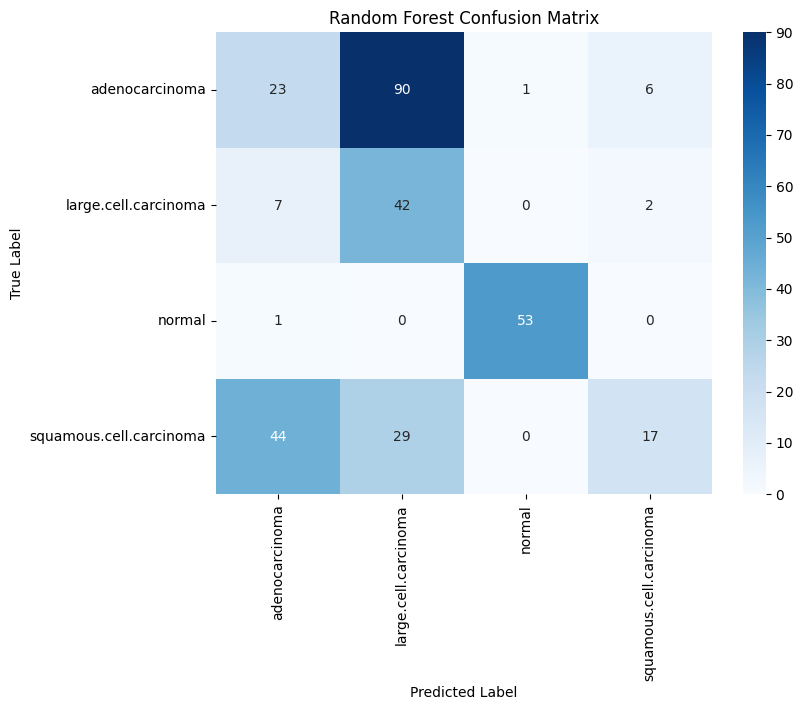

In [53]:
# Random Forest Model Definition and Hyperparameter Optimization
print("\n--- Random Forest Model Training and Optimization ---")

# Parameter grid to define
param_grid_rf = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [10, 20, None],      # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5]     # Minimum number of samples required to split an internal node
}

rf_model = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Run hyperparameter optimization on the training set
grid_search_rf.fit(X_train_final, y_train)

print(f"Random Forest Best Parameters: {grid_search_rf.best_params_}")
print(f"Random Forest Best Cross-Validation Accuracy: {grid_search_rf.best_score_:.4f}")

# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Evaluate on the test set
y_pred_rf = best_rf_model.predict(X_test_final)
print("\nRandom Forest Test Set Evaluation Report:")
print(classification_report(y_test, y_pred_rf))
print(f"Random Forest Test Set Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.2. K-Nearest Neighbors (KNN) Classifier


--- KNN Model Training and Optimization ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
KNN Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
KNN Best Cross-Validation Accuracy: 0.7501

KNN Test Set Evaluation Report:
              precision    recall  f1-score   support

           0       0.37      0.31      0.33       120
           1       0.26      0.67      0.37        51
           2       1.00      0.98      0.99        54
           3       0.43      0.14      0.22        90

    accuracy                           0.43       315
   macro avg       0.51      0.53      0.48       315
weighted avg       0.48      0.43      0.42       315

KNN Test Set Accuracy: 0.4349


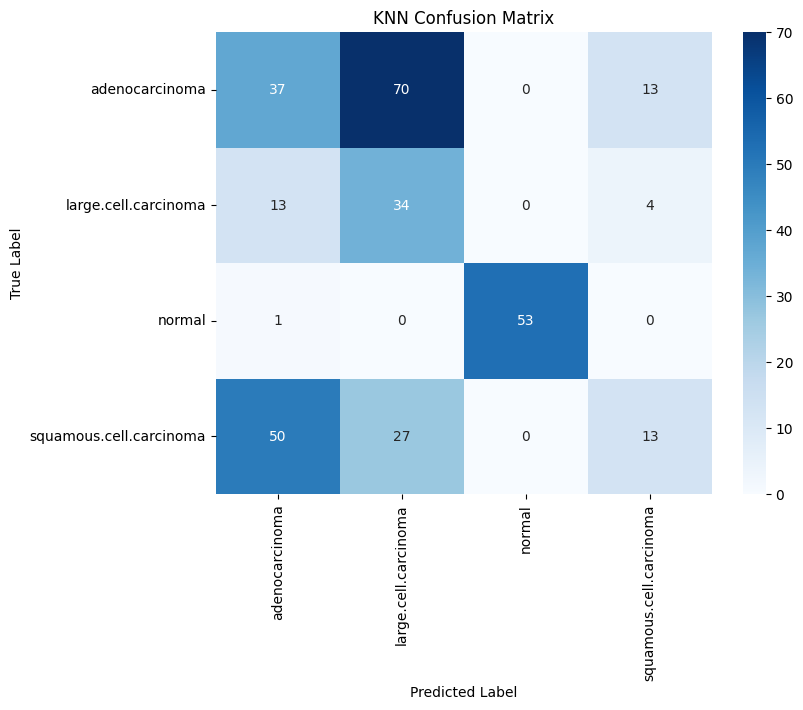

In [54]:
# K-Nearest Neighbors Model Definition and Hyperparameter Optimization
print("\n--- KNN Model Training and Optimization ---")

# Parameter grid to define
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],  # Number of neighbors
    'weights': ['uniform', 'distance'], # Weight function
    'metric': ['euclidean', 'manhattan'] # Distance metric
}

knn_model = KNeighborsClassifier()

grid_search_knn = GridSearchCV(estimator=knn_model, param_grid=param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Run hyperparameter optimization on the training set
grid_search_knn.fit(X_train_final, y_train)

print(f"KNN Best Parameters: {grid_search_knn.best_params_}")
print(f"KNN Best Cross-Validation Accuracy: {grid_search_knn.best_score_:.4f}")

# Get the best KNN model
best_knn_model = grid_search_knn.best_estimator_

# Evaluate on the test set
y_pred_knn = best_knn_model.predict(X_test_final)
print("\nKNN Test Set Evaluation Report:")
print(classification_report(y_test, y_pred_knn))
print(f"KNN Test Set Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 6. Model Evaluation and Visualization

In this section, we will evaluate the performance of the trained Random Forest and K-Nearest Neighbors (KNN) models in more detail. We will calculate Accuracy, macro and per-class F1-score, and macro and per-class AUC metrics on the test set. Additionally, we will visualize feature importance for Random Forest and permutation importance for KNN. Finally, we will compare and discuss the performance of the two models.

**Note:** Confusion matrices were visualized in the previous section.

In [55]:
from sklearn.metrics import roc_auc_score, f1_score

print("\n--- Model Metrics --- ")

# Random Forest Metrics
print("\nRandom Forest Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# F1-score (macro and per-class)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_per_class_rf = f1_score(y_test, y_pred_rf, average=None)
print(f"Macro F1-score: {f1_macro_rf:.4f}")
print(f"Per-Class F1-scores: {f1_per_class_rf}")

# AUC (macro and per-class - requires predict_proba)
y_pred_proba_rf = best_rf_model.predict_proba(X_test_final)
auc_macro_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='macro')
auc_per_class_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average=None)
print(f"Macro AUC: {auc_macro_rf:.4f}")
print(f"Per-Class AUCs: {auc_per_class_rf}")

# KNN Metrics
print("\nKNN Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

# F1-score (macro and per-class)
f1_macro_knn = f1_score(y_test, y_pred_knn, average='macro')
f1_per_class_knn = f1_score(y_test, y_pred_knn, average=None)
print(f"Macro F1-score: {f1_macro_knn:.4f}")
print(f"Per-Class F1-scores: {f1_per_class_knn}")

# AUC (macro and per-class - requires predict_proba)
y_pred_proba_knn = best_knn_model.predict_proba(X_test_final)
auc_macro_knn = roc_auc_score(y_test, y_pred_proba_knn, multi_class='ovr', average='macro')
auc_per_class_knn = roc_auc_score(y_test, y_pred_proba_knn, multi_class='ovr', average=None)
print(f"Macro AUC: {auc_macro_knn:.4f}")
print(f"Per-Class AUCs: {auc_per_class_knn}")


--- Model Metrics --- 

Random Forest Metrics:
Accuracy: 0.4286
Macro F1-score: 0.4773
Per-Class F1-scores: [0.23589744 0.39622642 0.98148148 0.29565217]
Macro AUC: 0.8012
Per-Class AUCs: [0.61363248 0.78773024 0.99964524 0.8037037 ]

KNN Metrics:
Accuracy: 0.4349
Macro F1-score: 0.4789
Per-Class F1-scores: [0.33484163 0.37362637 0.99065421 0.21666667]
Macro AUC: 0.7460
Per-Class AUCs: [0.53534188 0.7286839  1.         0.71995062]


### 6.1. Random Forest Feature Importance

/tmp/ipykernel_8116/2472773859.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='viridis')


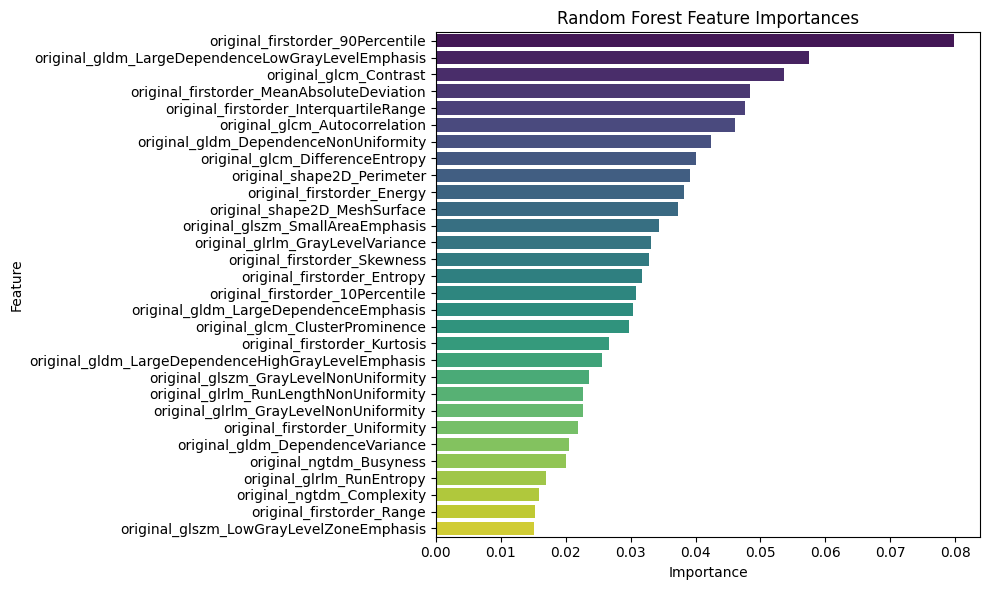

In [56]:
# Visualize feature importance for Random Forest

# Get feature importances from the best Random Forest model
feature_importances_rf = best_rf_model.feature_importances_
features_rf = X_train_final.columns

# Convert feature importances to a DataFrame and sort
importance_df_rf = pd.DataFrame({
    'Feature': features_rf,
    'Importance': feature_importances_rf
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 6.2. KNN Permutation Importance

/tmp/ipykernel_8116/3384665341.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_knn, palette='magma')


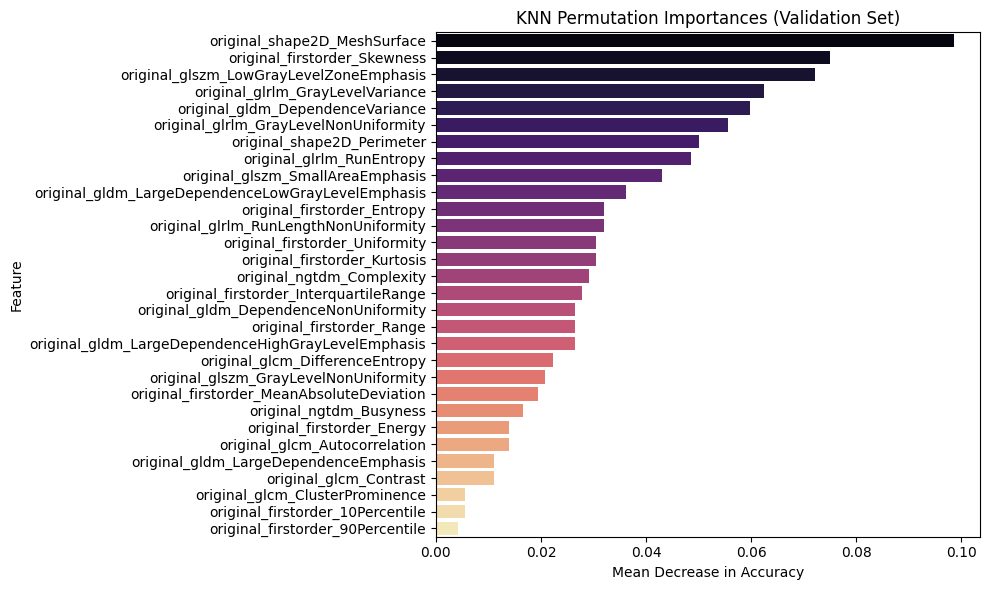

In [57]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for KNN (on the validation set)
# Permutation importance measures how much model performance decreases when a feature is randomly shuffled.

# Note: permutation_importance requires the model, data, and target.
# We will use the validation set.
result = permutation_importance(best_knn_model, X_valid_final, y_valid, n_repeats=10, random_state=42, n_jobs=-1)

# Get and sort feature importances
sorted_idx = result.importances_mean.argsort()[::-1]

importance_df_knn = pd.DataFrame({
    'Feature': X_valid_final.columns[sorted_idx],
    'Importance': result.importances_mean[sorted_idx]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_knn, palette='magma')
plt.title('KNN Permutation Importances (Validation Set)')
plt.xlabel('Mean Decrease in Accuracy')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 6.3. Model Comparison and Discussion

In [58]:
# Create a DataFrame comparing the models
comparison_data = {
    'Model': ['Random Forest', 'KNN'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_knn)],
    'Macro F1-score': [f1_macro_rf, f1_macro_knn],
    'Macro AUC': [auc_macro_rf, auc_macro_knn]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Model')

print("\n--- Model Comparison Table ---")
display(df_comparison)


--- Model Comparison Table ---


,Accuracy,Macro F1-score,Macro AUC
Model,,,
Random Forest,0.428571,0.477314,0.801178
KNN,0.434921,0.478947,0.745994
